In [3]:
import sys
import os

# Adjust the path to where the src folder is located
sys.path.append(os.path.abspath(os.path.join('..', 'src')))


In [4]:
import torch
from torch.utils.data import Dataset, DataLoader
import tqdm
from language_models.dictionary_corpus import Dictionary, Corpus, tokenize
from language_models.model import RNNModel as lstm
from language_models.utils import move_to_device
import random
import pandas as pd
from collections import defaultdict
import numpy as np
import argparse
import re

In [48]:
batch_size = 1024
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
data_path = "/scratch2/mrenaudin/colorlessgreenRNNs/english_data"
dictionary = Dictionary(data_path)
nounpp = "/scratch2/mrenaudin/colorlessgreenRNNs/NounPP/Stimuli/nounpp.txt"
checkpoint_dir = "/scratch2/mrenaudin/colorlessgreenRNNs/checkpoints/lstm_sgd_lr10"

In [34]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [35]:
def load_model(checkpoint_name):
    model = lstm("LSTM", 50001, 650, 650, 2, 0.2, False).to(device)
    with open(checkpoint_name, "rb") as f:
        state_dict = torch.load(f, map_location=device)
        model.load_state_dict(state_dict['model_state_dict'])
    return model

In [36]:
class NounPPDataset(Dataset):
    def __init__(self, nounpp_file, dictionary):
        self.sentences = []
        self.conditions = []
        self.correct = []
        self.wrong = []
        self.encoded_sentences = []
        self.encoded_correct = []
        self.encoded_wrong = []
        self.dictionary = dictionary

        with open(nounpp_file, "r") as f:
            for line in f:
                line = line.split()
                sentence = line[1:7]
                condition = " ".join(line[7:9])
                wrong = line[9]
                correct = line[6]
                encoded_sentence = [
                    self.dictionary.word2idx.get(
                        word, self.dictionary.word2idx.get("<unk>")
                    )
                    for word in sentence
                ]
                encoded_correct = self.dictionary.word2idx.get(
                    correct, self.dictionary.word2idx.get("<unk>")
                )
                encoded_wrong = self.dictionary.word2idx.get(
                    wrong, self.dictionary.word2idx.get("<unk>")
                )

                self.sentences.append(sentence)
                self.conditions.append(condition)
                self.correct.append(correct)
                self.wrong.append(wrong)
                self.encoded_sentences.append(encoded_sentence)
                self.encoded_correct.append(encoded_correct)
                self.encoded_wrong.append(encoded_wrong)

    def __len__(self):
        return len(self.sentences)

    def __getitem__(self, idx):
        return {
            "sentence": self.sentences[idx],
            "encoded_sentence": torch.tensor(
                self.encoded_sentences[idx], dtype=torch.long
            ),
            "correct": self.correct[idx],
            "encoded_correct": torch.tensor(
                self.encoded_correct[idx], dtype=torch.long
            ),
            "wrong": self.wrong[idx],
            "encoded_wrong": torch.tensor(self.encoded_wrong[idx], dtype=torch.long),
            "condition": self.conditions[idx],
        }

In [37]:
def collate_fn(batch):
    """Custom collate function to properly handle sentences as lists of strings."""
    sentences = [item["sentence"] for item in batch]  # Keep lists of words as they are
    encoded_sentences = torch.stack(
        [item["encoded_sentence"] for item in batch]
    )  # Stack tensors
    encoded_correct = torch.stack([item["encoded_correct"] for item in batch])
    encoded_wrong = torch.stack([item["encoded_wrong"] for item in batch])
    correct = [item["correct"] for item in batch]
    wrong = [item["wrong"] for item in batch]
    conditions = [item["condition"] for item in batch]

    return {
        "sentence": sentences,
        "encoded_sentence": encoded_sentences,
        "correct": correct,
        "encoded_correct": encoded_correct,
        "wrong": wrong,
        "encoded_wrong": encoded_wrong,
        "condition": conditions,
    }

In [38]:
# Priming
init_sentence = " ".join(
    [
        "In service , the aircraft was operated by a crew of five and could accommodate either 30 paratroopers , 32 <unk> and 28 sitting casualties , or 50 fully equipped troops . <eos>",
        'He even speculated that technical classes might some day be held " for the better training of workmen in their several crafts and industries . <eos>',
        "After the War of the Holy League in 1537 against the Ottoman Empire , a truce between Venice and the Ottomans was created in 1539 . <eos>",
        'Moore says : " Tony and I had a good <unk> and off-screen relationship , we are two very different people , but we did share a sense of humour " . <eos>',
        "<unk> is also the basis for online games sold through licensed lotteries . <eos>",
    ]
)


def feed_input(model, hidden, w):
    inp = torch.autograd.Variable(
        torch.LongTensor([[dictionary.word2idx[w]]]).to(device)
    )
    out, hidden = model(inp, hidden)
    return out, hidden


def feed_sentence(model, h, sentence):
    outs = []
    for w in sentence:
        out, h = feed_input(model, h, w)
        outs.append(torch.nn.functional.log_softmax(out[0]).unsqueeze(0))
    return outs, h

In [39]:
def eval(model, test_dataloader, init_sentence):
    condition_accuracies = defaultdict(int)
    condition_counts = defaultdict(int)
    correct_pred = 0
    sentence_details = []

    model.eval()

    hidden = model.init_hidden(1)
    init_out, init_h = feed_sentence(model, hidden, init_sentence.split(" "))

    with torch.no_grad():
        for batch in test_dataloader:
            out = None
            written = batch["sentence"]
            sentence = batch["encoded_sentence"].to(device)
            correct = batch["encoded_correct"].to(device)
            wrong = batch["encoded_wrong"].to(device)
            condition = batch["condition"]
            batch_size = sentence.size(0)
            hidden = (
                init_h[0].expand(-1, batch_size, -1).contiguous(),
                init_h[1].expand(-1, batch_size, -1).contiguous(),
            )
            for w in range(sentence.shape[1] - 1):
                word = torch.autograd.Variable(sentence[:, w].unsqueeze(0)).to(device)
                out, hidden = model(word, hidden)

            log_probs = torch.nn.functional.log_softmax(out, dim=-1)
            correct_log_probs = log_probs[0, torch.arange(batch_size), correct]
            wrong_log_probs = log_probs[0, torch.arange(batch_size), wrong]
            correct_predictions = correct_log_probs >= wrong_log_probs
            for i in range(batch_size):
                cond = condition[i]
                pred = correct_predictions[i].item()
                condition_counts[cond] += 1
                condition_accuracies[cond] += pred

                sentence_details.append(
                    {
                        "sentence": written[i],
                        "condition": condition[i],
                        "correct_log_prob": correct_log_probs[i],
                        "wrong_log_prob": wrong_log_probs[i],
                        "model_prefers_correct": pred,
                    }
                )
    final_accuracies = {
        cond: condition_accuracies[cond] / condition_counts[cond]
        for cond in condition_accuracies
    }

    return final_accuracies

In [40]:
test_dataset = NounPPDataset(nounpp, dictionary)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, collate_fn=collate_fn)

In [41]:
def ablate_neuron(model, l, n, num_neurons):
    gate_indices = torch.tensor(
                [
                    n,
                    n + num_neurons,
                    n + num_neurons * 2,
                    n + num_neurons * 3,
                ]
            )
    if l == 0:
        # Ablate layer 0 neuron
        model.rnn.weight_ih_l0[gate_indices] = 0
        model.rnn.weight_hh_l0[gate_indices] = 0
        model.rnn.bias_ih_l0[gate_indices] = 0
        model.rnn.bias_hh_l0[gate_indices] = 0
    elif l == 1:
        # Ablate layer 1 neuron
        model.rnn.weight_ih_l1[gate_indices] = 0
        model.rnn.weight_hh_l1[gate_indices] = 0
        model.rnn.bias_ih_l1[gate_indices] = 0
        model.rnn.bias_hh_l1[gate_indices] = 0
    return model, gate_indices

In [42]:
def restore_neuron(model, l, gate_indices, weights):
    if l == 0:
        model.rnn.weight_ih_l0[gate_indices] = weights["weight_ih_l0"][gate_indices]    
        model.rnn.weight_hh_l0[gate_indices] = weights["weight_hh_l0"][gate_indices]
        model.rnn.bias_ih_l0[gate_indices] = weights["bias_ih_l0"][gate_indices]
        model.rnn.bias_hh_l0[gate_indices] = weights["bias_hh_l0"][gate_indices]
    elif l == 1:
        model.rnn.weight_ih_l1[gate_indices] = weights["weight_ih_l1"][gate_indices]
        model.rnn.weight_hh_l1[gate_indices] = weights["weight_hh_l1"][gate_indices]
        model.rnn.bias_ih_l1[gate_indices] = weights["bias_ih_l1"][gate_indices]
        model.rnn.bias_hh_l1[gate_indices] = weights["bias_hh_l1"][gate_indices]
    return model

In [43]:
def cache_weights(model):
    weights = {
    "weight_ih_l0": model.rnn.weight_ih_l0.clone(),
    "weight_hh_l0": model.rnn.weight_hh_l0.clone(),
    "bias_ih_l0": model.rnn.bias_ih_l0.clone(),
    "bias_hh_l0": model.rnn.bias_hh_l0.clone(),
    "weight_ih_l1": model.rnn.weight_ih_l1.clone(),
    "weight_hh_l1": model.rnn.weight_hh_l1.clone(),
    "bias_ih_l1": model.rnn.bias_ih_l1.clone(),
    "bias_hh_l1": model.rnn.bias_hh_l1.clone(),
}
    return weights

In [45]:
def evaluate_checkpoint(model, test_loader, init_sentence, layer=2, num_neurons=650):
    results = {}
    original_accuracies = eval(model, test_loader, init_sentence)
    results["original"] = original_accuracies

    ####caching
    weights= cache_weights(model)

    for l in range(layer):
        for n in range(num_neurons):
            with torch.no_grad():
                
                model, gate_indices = ablate_neuron(model, l, n, num_neurons)
                res = eval(model, test_loader, init_sentence)
                results[f"layer_{l}_neuron_{n}"] = res
                #restore weights
                model = restore_neuron(model, l, gate_indices, weights)
    return results
        

In [49]:
checkpoint_files = [
    f
    for f in os.listdir(checkpoint_dir)
    if f.startswith("epoch_") and f.endswith(".pt")
]

In [50]:
for checkpoint_file in checkpoint_files:
    results = {}
    checkpoint_path = os.path.join(checkpoint_dir, checkpoint_file)
    checkpoint_name = checkpoint_file
    model = load_model(checkpoint_path)
    res = evaluate_checkpoint(model, test_dataloader, init_sentence)
    results[checkpoint_name] = res



/tmp/ipykernel_1533061/125199508.py:25: UserWarning: Implicit dimension choice for log_softmax has been deprecated. Change the call to include dim=X as an argument.
  outs.append(torch.nn.functional.log_softmax(out[0]).unsqueeze(0))


KeyboardInterrupt: 

# Impact on performance of the 3 most detrimental neurons at the beginning of the training through time

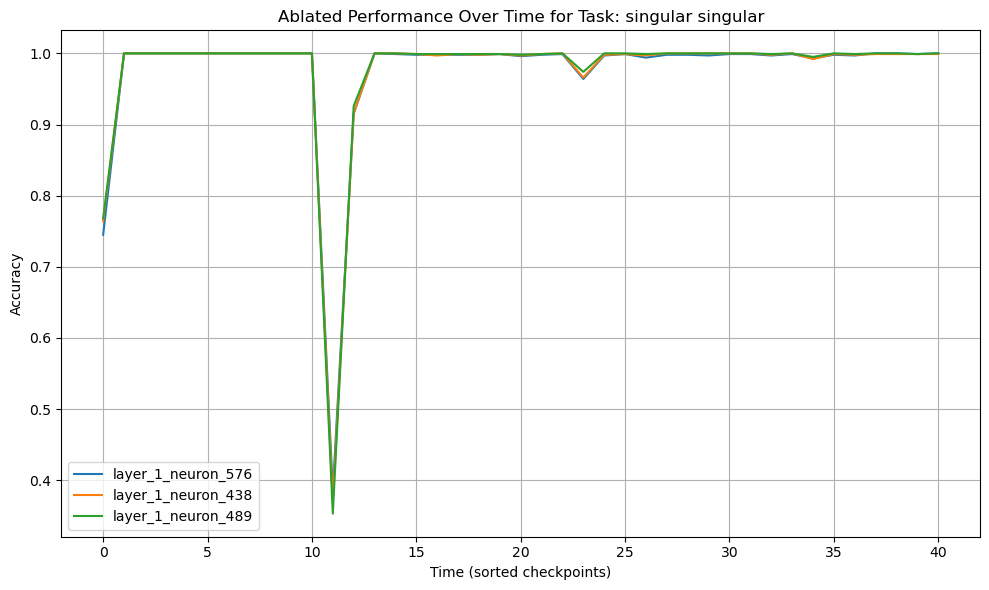

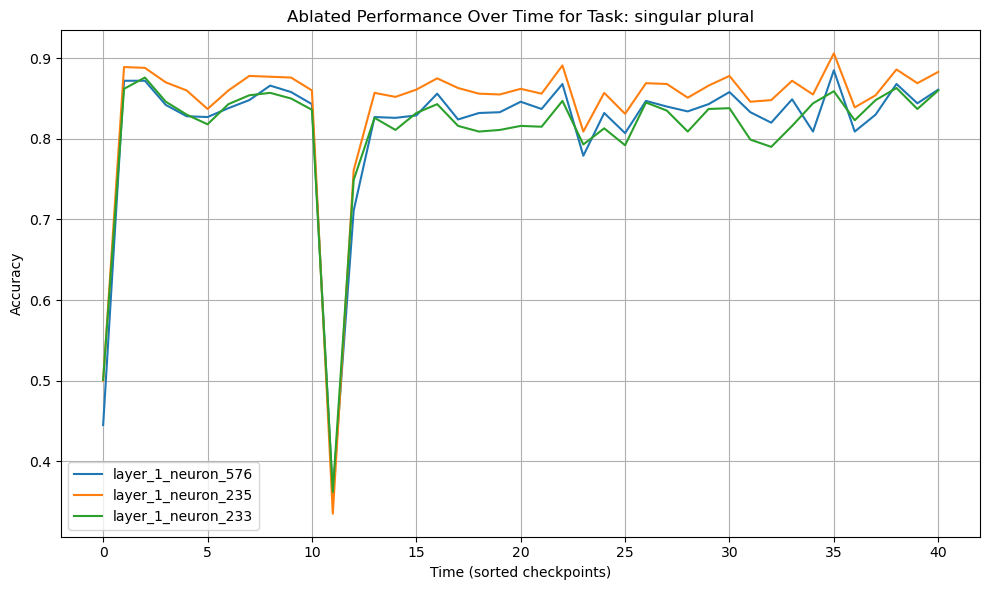

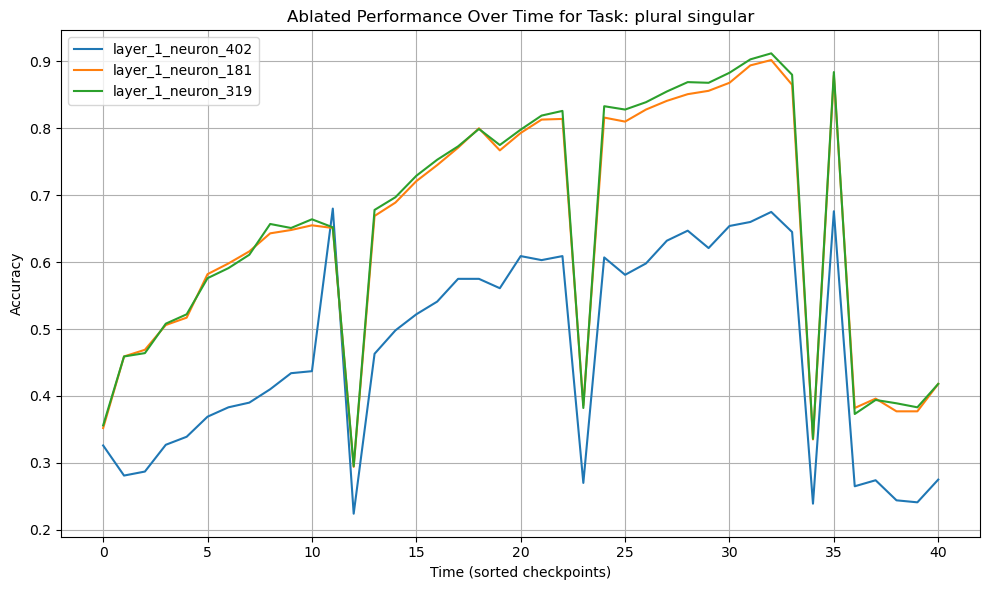

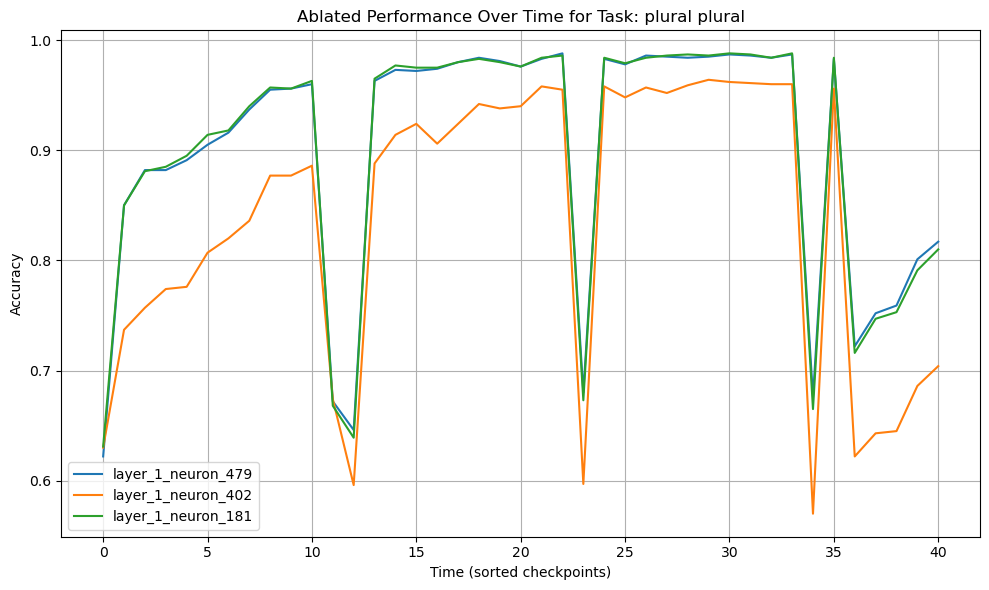

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import pickle
from collections import defaultdict

# Load the dictionary
with open("/scratch2/mrenaudin/colorlessgreenRNNs/results.pkl", "rb") as f:
    results = pickle.load(f)


first_epoch = sorted(results.keys())[0]
first_data = results[first_epoch]
original = first_data['original']

# Compute performance drop for each neuron and each task
task_detriment = defaultdict(list)  # task -> list of (neuron, drop)

for neuron, values in first_data.items():
    if neuron == "original":
        continue
    for task in original:
        drop = original[task] - values[task]
        task_detriment[task].append((neuron, drop))

# Keep top 3 neurons per task with max drop
top3_by_task = {
    task: sorted(neuron_drops, key=lambda x: x[1], reverse=True)[:3]
    for task, neuron_drops in task_detriment.items()
}
# Sort time keys
time_points = sorted(results.keys())

# Initialize tracking dictionary: task -> neuron -> list of accuracies
performance_through_time = defaultdict(lambda: defaultdict(list))

for time in time_points:
    data = results[time]
    for task, top_neurons in top3_by_task.items():
        for neuron, _ in top_neurons:
            acc = data[neuron][task] if neuron in data else None
            performance_through_time[task][neuron].append(acc)
for task, neuron_dict in performance_through_time.items():
    plt.figure(figsize=(10, 6))
    for neuron, scores in neuron_dict.items():
        plt.plot(range(len(scores)), scores, label=neuron)
    plt.title(f"Ablated Performance Over Time for Task: {task}")
    plt.xlabel("Time (sorted checkpoints)")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()



### Les drops dans la distribution des eigenvalues : plus de neurones spécialisés

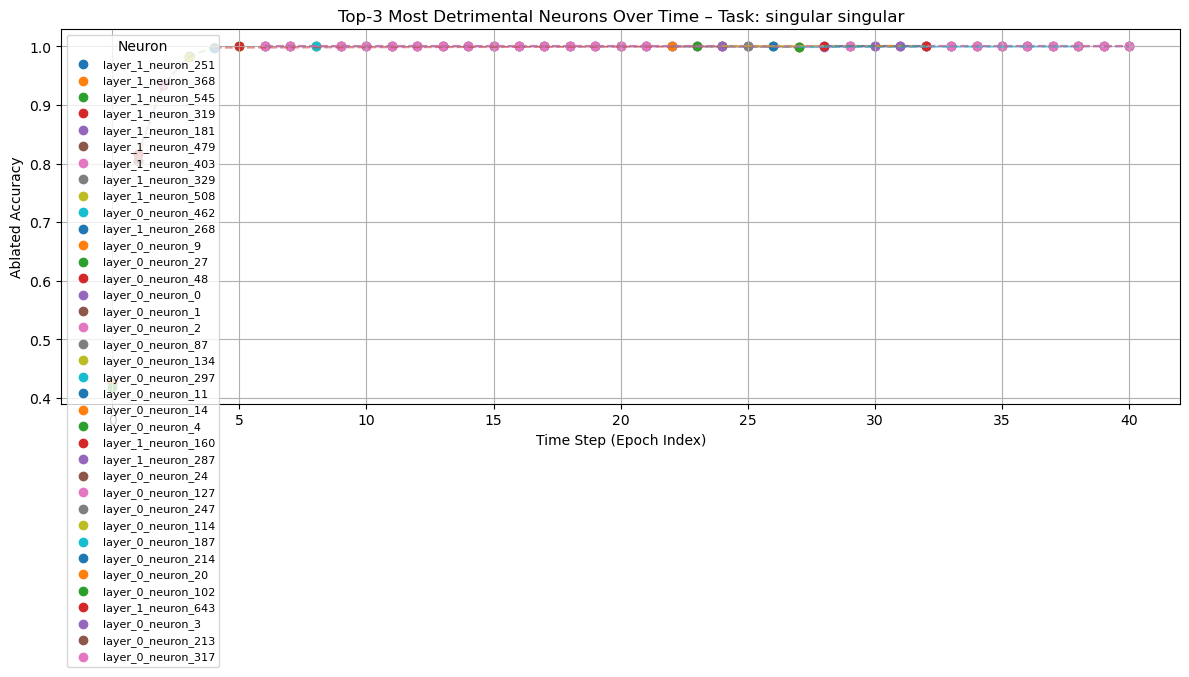

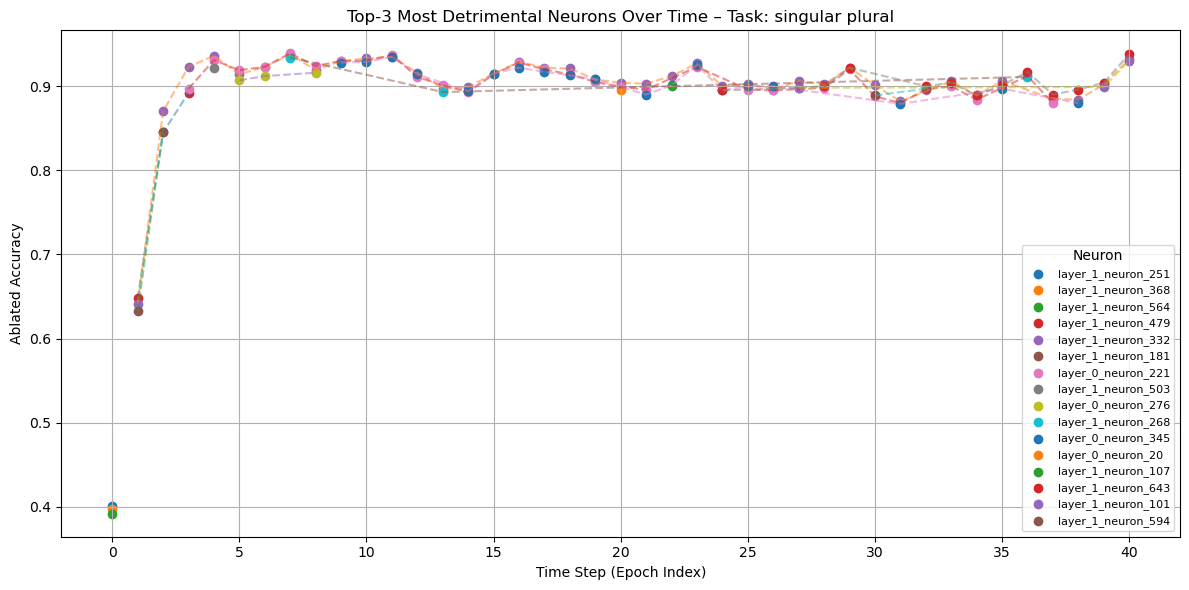

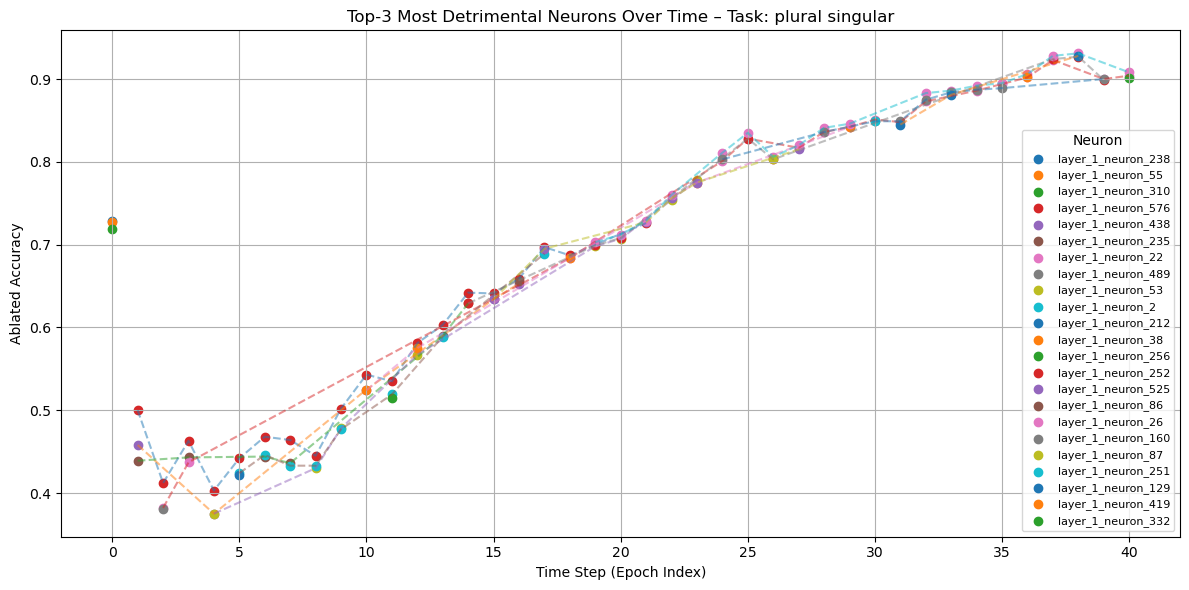

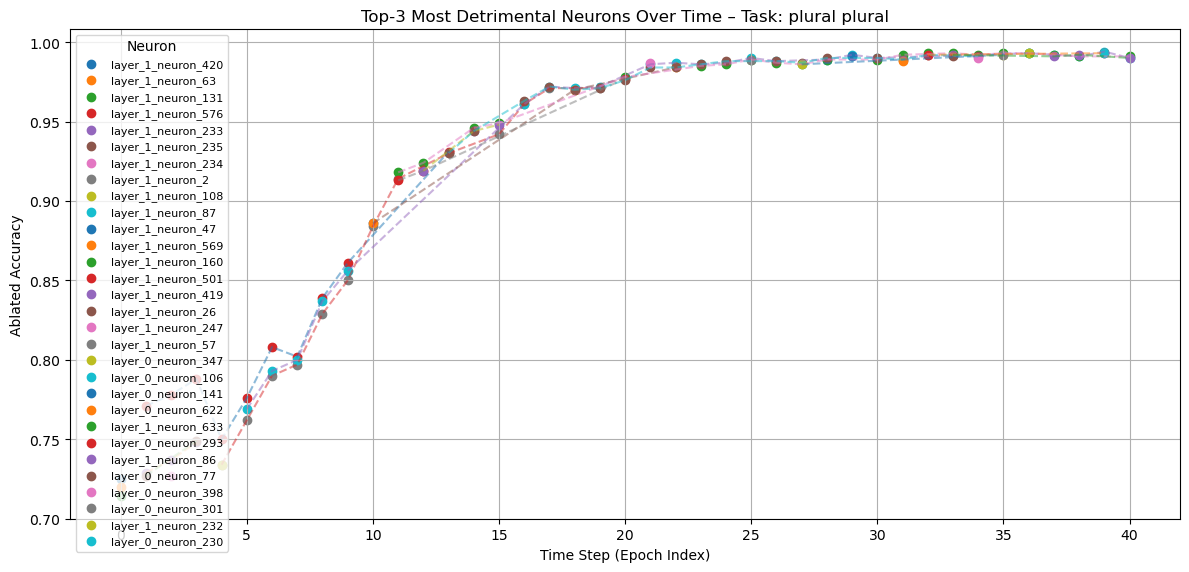

In [ ]:
import pickle
import matplotlib.pyplot as plt
from collections import defaultdict

# Load data
with open("/scratch2/mrenaudin/colorlessgreenRNNs/results.pkl", "rb") as f:
    results = pickle.load(f)

# Sort epochs
#time_points = sorted(results.keys())

# For each task, store a list of (time_idx, neuron, ablated_accuracy)
task_top3_points = defaultdict(list)

for t_idx, time in enumerate(time_points):
    data = results[time]
    original = data['original']

    # Compute drop in accuracy for each neuron and task
    task_drops = defaultdict(list)
    for neuron, accs in data.items():
        if neuron == "original":
            continue
        for task in original:
            drop = original[task] - accs[task]
            task_drops[task].append((neuron, drop, accs[task]))

    # For each task, store top 3 neurons
    for task, drops in task_drops.items():
        top3 = sorted(drops, key=lambda x: x[1], reverse=True)[:3]
        for neuron, drop, ablated_acc in top3:
            task_top3_points[task].append((t_idx, neuron, ablated_acc))

# Now plot
for task, points in task_top3_points.items():
    plt.figure(figsize=(12, 6))
    plt.title(f"Top-3 Most Detrimental Neurons Over Time – Task: {task}")
    plt.xlabel("Time Step (Epoch Index)")
    plt.ylabel("Ablated Accuracy")

    # Group by neuron to connect them across time
    neuron_to_points = defaultdict(list)
    for t_idx, neuron, acc in points:
        neuron_to_points[neuron].append((t_idx, acc))

    # Plot scatter points and connect same neurons
    for neuron, time_accs in neuron_to_points.items():
        time_accs = sorted(time_accs)
        x, y = zip(*time_accs)
        plt.scatter(x, y, label=neuron)
        if len(x) > 1:
            plt.plot(x, y, linestyle='--', alpha=0.5)

    plt.legend(title="Neuron", fontsize=8, title_fontsize=10)
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [23]:
with open("/scratch2/mrenaudin/colorlessgreenRNNs/results.pkl", "rb") as f:
    results = pickle.load(f)

In [25]:
results

{'epoch_1_batch_0.pt': {'original': {'singular singular': 0.365,
   'singular plural': 0.338,
   'plural singular': 0.658,
   'plural plural': 0.677},
  'layer_0_neuron_0': {'singular singular': 0.364,
   'singular plural': 0.336,
   'plural singular': 0.66,
   'plural plural': 0.678},
  'layer_0_neuron_1': {'singular singular': 0.357,
   'singular plural': 0.332,
   'plural singular': 0.668,
   'plural plural': 0.679},
  'layer_0_neuron_2': {'singular singular': 0.365,
   'singular plural': 0.334,
   'plural singular': 0.657,
   'plural plural': 0.672},
  'layer_0_neuron_3': {'singular singular': 0.364,
   'singular plural': 0.338,
   'plural singular': 0.66,
   'plural plural': 0.677},
  'layer_0_neuron_4': {'singular singular': 0.365,
   'singular plural': 0.335,
   'plural singular': 0.658,
   'plural plural': 0.671},
  'layer_0_neuron_5': {'singular singular': 0.368,
   'singular plural': 0.338,
   'plural singular': 0.658,
   'plural plural': 0.676},
  'layer_0_neuron_6': {'singu

In [37]:
# Select the time step
time_step = 'epoch_40.pt'

# Select the task(s) you're interested in
tasks = ['singular singular', 'singular plural', 'plural singular', 'plural plural']

# Get performances
original_perf = results[time_step]['original']
ablated_perf = results[time_step].get('layer_1_neuron_402')

# Print results
print(f"Performance at {time_step}:\n")

for task in tasks:
    orig = original_perf[task]
    ablated = ablated_perf[task] if ablated_perf else 'N/A'
    delta = (orig - ablated) if ablated_perf else 'N/A'
    print(f"  Task: {task}")
    print(f"    Original: {orig:.3f}")
    print(f"    Without layer_1_neuron_420: {ablated:.3f}")
    print(f"    Drop: {delta:.3f}\n")


Performance at epoch_40.pt:

  Task: singular singular
    Original: 1.000
    Without layer_1_neuron_420: 0.989
    Drop: 0.011

  Task: singular plural
    Original: 0.908
    Without layer_1_neuron_420: 0.733
    Drop: 0.175

  Task: plural singular
    Original: 0.882
    Without layer_1_neuron_420: 0.676
    Drop: 0.206

  Task: plural plural
    Original: 0.987
    Without layer_1_neuron_420: 0.956
    Drop: 0.031



In [27]:
time_points = sorted(results.keys())
time_points

['epoch_1.pt',
 'epoch_10.pt',
 'epoch_11.pt',
 'epoch_12.pt',
 'epoch_13.pt',
 'epoch_14.pt',
 'epoch_15.pt',
 'epoch_16.pt',
 'epoch_17.pt',
 'epoch_18.pt',
 'epoch_19.pt',
 'epoch_1_batch_0.pt',
 'epoch_2.pt',
 'epoch_20.pt',
 'epoch_21.pt',
 'epoch_22.pt',
 'epoch_23.pt',
 'epoch_24.pt',
 'epoch_25.pt',
 'epoch_26.pt',
 'epoch_27.pt',
 'epoch_28.pt',
 'epoch_29.pt',
 'epoch_3.pt',
 'epoch_30.pt',
 'epoch_31.pt',
 'epoch_32.pt',
 'epoch_33.pt',
 'epoch_34.pt',
 'epoch_35.pt',
 'epoch_36.pt',
 'epoch_37.pt',
 'epoch_38.pt',
 'epoch_39.pt',
 'epoch_4.pt',
 'epoch_40.pt',
 'epoch_5.pt',
 'epoch_6.pt',
 'epoch_7.pt',
 'epoch_8.pt',
 'epoch_9.pt']

In [35]:
time_points = [
    'epoch_1_batch_0.pt', 'epoch_1.pt', 'epoch_2.pt', 'epoch_3.pt', 'epoch_4.pt', 
    'epoch_5.pt', 'epoch_6.pt', 'epoch_7.pt', 'epoch_8.pt', 'epoch_9.pt', 
    'epoch_10.pt', 'epoch_11.pt', 'epoch_12.pt', 'epoch_13.pt', 'epoch_14.pt', 
    'epoch_15.pt', 'epoch_16.pt', 'epoch_17.pt', 'epoch_18.pt', 'epoch_19.pt', 
    'epoch_20.pt', 'epoch_21.pt', 'epoch_22.pt', 'epoch_23.pt', 'epoch_24.pt', 
    'epoch_25.pt', 'epoch_26.pt', 'epoch_27.pt', 'epoch_28.pt', 'epoch_29.pt', 
    'epoch_30.pt', 'epoch_31.pt', 'epoch_32.pt', 'epoch_33.pt', 'epoch_34.pt', 
    'epoch_35.pt', 'epoch_36.pt', 'epoch_37.pt', 'epoch_38.pt', 'epoch_39.pt', 
    'epoch_40.pt'
]

In [39]:
checkpoint_dir_str = "/scratch2/mrenaudin/colorlessgreenRNNs/checkpoints/lstm_sgd_lr10_no_clip"
checkpoint_files = sorted(os.listdir(checkpoint_dir_str))
print(checkpoint_files)

['epoch_1.pt', 'epoch_10.pt', 'epoch_11.pt', 'epoch_12.pt', 'epoch_13.pt', 'epoch_14.pt', 'epoch_15.pt', 'epoch_16.pt', 'epoch_17.pt', 'epoch_18.pt', 'epoch_19.pt', 'epoch_1_batch_0.pt', 'epoch_2.pt', 'epoch_20.pt', 'epoch_21.pt', 'epoch_22.pt', 'epoch_23.pt', 'epoch_24.pt', 'epoch_25.pt', 'epoch_26.pt', 'epoch_27.pt', 'epoch_28.pt', 'epoch_29.pt', 'epoch_3.pt', 'epoch_30.pt', 'epoch_31.pt', 'epoch_32.pt', 'epoch_33.pt', 'epoch_34.pt', 'epoch_35.pt', 'epoch_36.pt', 'epoch_37.pt', 'epoch_38.pt', 'epoch_39.pt', 'epoch_4.pt', 'epoch_40.pt', 'epoch_5.pt', 'epoch_6.pt', 'epoch_7.pt', 'epoch_8.pt', 'epoch_9.pt', 'weights']


## 2. Are specialized neurons memory neurons ? (forget gate, input gate, cell state, hidden state)

# Plot eigenvalues

In [28]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.lines import Line2D
import plotly.express as px
import pandas as pd
import plotly.graph_objects as go
import plotly.colors as pc
import os

In [29]:
#weight tensors for layer 1
l1_forget_ih = torch.load('/scratch2/mrenaudin/colorlessgreenRNNs/checkpoints/lstm_adam/weights/layer1_forget_gate_ih.pt')
l1_forget_hh = torch.load('/scratch2/mrenaudin/colorlessgreenRNNs/checkpoints/lstm_adam/weights/layer1_forget_gate_hh.pt')
l1_input_ih = torch.load('/scratch2/mrenaudin/colorlessgreenRNNs/checkpoints/lstm_adam/weights/layer1_input_gate_ih.pt')
l1_input_hh = torch.load('/scratch2/mrenaudin/colorlessgreenRNNs/checkpoints/lstm_adam/weights/layer1_input_gate_hh.pt')
l1_cell_ih = torch.load('/scratch2/mrenaudin/colorlessgreenRNNs/checkpoints/lstm_adam/weights/layer1_cell_gate_ih.pt')
l1_cell_hh = torch.load('/scratch2/mrenaudin/colorlessgreenRNNs/checkpoints/lstm_adam/weights/layer1_cell_gate_hh.pt')
l1_output_ih = torch.load('/scratch2/mrenaudin/colorlessgreenRNNs/checkpoints/lstm_adam/weights/layer1_output_gate_ih.pt')
l1_output_hh = torch.load('/scratch2/mrenaudin/colorlessgreenRNNs/checkpoints/lstm_adam/weights/layer1_output_gate_hh.pt')

#weight tensors for layer 2
l2_forget_ih = torch.load('/scratch2/mrenaudin/colorlessgreenRNNs/checkpoints/lstm_adam/weights/layer2_forget_gate_ih.pt')
l2_forget_hh = torch.load('/scratch2/mrenaudin/colorlessgreenRNNs/checkpoints/lstm_adam/weights/layer2_forget_gate_hh.pt')
l2_input_ih = torch.load('/scratch2/mrenaudin/colorlessgreenRNNs/checkpoints/lstm_adam/weights/layer2_input_gate_ih.pt')
l2_input_hh = torch.load('/scratch2/mrenaudin/colorlessgreenRNNs/checkpoints/lstm_adam/weights/layer2_input_gate_hh.pt')
l2_cell_ih = torch.load('/scratch2/mrenaudin/colorlessgreenRNNs/checkpoints/lstm_adam/weights/layer2_cell_gate_ih.pt')
l2_cell_hh = torch.load('/scratch2/mrenaudin/colorlessgreenRNNs/checkpoints/lstm_adam/weights/layer2_cell_gate_hh.pt')
l2_output_ih = torch.load('/scratch2/mrenaudin/colorlessgreenRNNs/checkpoints/lstm_adam/weights/layer2_output_gate_ih.pt')
l2_output_hh = torch.load('/scratch2/mrenaudin/colorlessgreenRNNs/checkpoints/lstm_adam/weights/layer2_output_gate_hh.pt')

In [30]:
num_checkpoints = l1_forget_ih.shape[0]
num_checkpoints

41

In [31]:
def get_sv_whole_layer(forget_ih, forget_hh, input_ih, input_hh, cell_ih, cell_hh, output_ih, output_hh, num_checkpoints):

    all_singular_values = []

    # For each checkpoint
    for i in range(num_checkpoints):
        # Stack all input-to-hidden weights
        ih_combined = torch.cat([
            forget_ih[i],
            input_ih[i],
            cell_ih[i],
            output_ih[i]
        ], dim=0)
        
        # Stack all hidden-to-hidden weights
        hh_combined = torch.cat([
            forget_hh[i],
            input_hh[i],
            cell_hh[i],
            output_hh[i]
        ], dim=0)
        
        # Combine all weights horizontally (concatenate along input dimension)
        #  ih is [hidden_size, input_size] and hh is [hidden_size, hidden_size] (https://pytorch.org/docs/stable/generated/torch.nn.LSTM.html)
        all_weights = torch.cat([ih_combined, hh_combined], dim=1)
        
        # Compute singular values
        u, s, v = torch.svd(all_weights)
        
        # Store singular values for this checkpoint
        all_singular_values.append(s)
    return all_singular_values

In [32]:
l1_sv = get_sv_whole_layer(l1_forget_ih, l1_forget_hh, l1_input_ih, l1_input_hh, l1_cell_ih, l1_cell_hh, l1_output_ih, l1_output_hh, num_checkpoints)

In [34]:
for i in range(num_checkpoints):
    print(i)
    print(l1_sv[i])


0
tensor([49.6143, 45.9565, 43.1528,  ...,  1.0893,  1.0826,  1.0668])
1
tensor([72.1040, 58.9249, 50.4150,  ...,  2.8217,  2.7834,  2.7786])
2
tensor([73.2653, 60.7263, 51.6881,  ...,  2.8610,  2.8385,  2.7989])
3
tensor([74.5117, 62.4274, 52.9325,  ...,  2.9063,  2.8820,  2.8372])
4
tensor([75.7530, 64.0260, 54.3372,  ...,  2.9799,  2.9585,  2.9210])
5
tensor([76.8533, 65.5649, 55.5766,  ...,  2.9786,  2.9243,  2.9020])
6
tensor([78.0647, 67.1572, 56.9304,  ...,  3.0140,  2.9949,  2.9694])
7
tensor([79.2066, 68.6091, 58.2728,  ...,  2.9981,  2.9861,  2.9574])
8
tensor([80.3882, 69.8495, 59.5546,  ...,  3.0597,  3.0199,  2.9286])
9
tensor([81.6300, 71.0264, 60.7331,  ...,  3.0442,  3.0175,  2.9816])
10
tensor([82.9292, 72.1162, 62.0790,  ...,  3.0543,  3.0228,  3.0016])
11
tensor([1.9543, 1.9531, 1.9501,  ..., 0.3510, 0.3463, 0.3419])
12
tensor([53.7469, 44.7289, 42.6171,  ...,  1.5132,  1.5093,  1.4899])
13
tensor([84.3456, 73.2110, 63.2939,  ...,  3.0995,  3.0567,  3.0325])
14
tenso